In [2]:
import re
from pathlib import Path
import pandas as pd

# -------- CONFIG --------
DATA_DIR = Path("./combined")  
# ------------------------

FILENAME_RE = re.compile(
    r"(?P<tsp>.+)_(?P<cities>\d+)_(?P<threads>\d+)\.txt"
)

ROW_RE = re.compile(
    r"^\s*(\d+)\s+(Sequential|Parallel)\s+([\d.]+)\s+(N/A|[\d.]+)\s+(N/A|[\d.]+)"
)

def parse_file(filepath: Path):
    """
    Parse one experiment file into a list of dict rows.
    """
    match = FILENAME_RE.match(filepath.name)
    if not match:
        return []

    meta = match.groupdict()
    rows = []

    with filepath.open("r", encoding="utf-8") as f:
        for line in f:
            m = ROW_RE.match(line)
            if not m:
                continue

            cutoff, run_type, time_s, speedup, efficiency = m.groups()

            rows.append({
                "tsp_file": meta["tsp"],
                "cities": int(meta["cities"]),
                "threads": int(meta["threads"]),
                "cutoff": int(cutoff),
                "run_type": run_type,
                "time_s": float(time_s),
                "speedup": None if speedup == "N/A" else float(speedup),
                "efficiency_pct": None if efficiency == "N/A" else float(efficiency),
                "source_file": filepath.name
            })

    return rows


def collect_all_data(data_dir: Path) -> pd.DataFrame:
    all_rows = []

    for file in data_dir.glob("*.txt"):
        all_rows.extend(parse_file(file))

    df = pd.DataFrame(all_rows)

    if df.empty:
        raise RuntimeError("No valid data parsed. Check file format or path.")

    return df



In [4]:

# -------- RUN --------
df = collect_all_data(DATA_DIR)

# Basic normalization / sorting
df = df.sort_values(
    by=["tsp_file", "cities", "threads", "cutoff", "run_type"]
).reset_index(drop=True)

print(df.head())


print(df)

  tsp_file  cities  threads  cutoff    run_type  time_s  speedup  \
0     dj38       8        1       0    Parallel   0.001    0.183   
1     dj38       8        1       0  Sequential   0.000      NaN   
2     dj38       8        1       1    Parallel   0.001    0.247   
3     dj38       8        1       2    Parallel   0.001    0.338   
4     dj38       8        1       3    Parallel   0.000    0.395   

   efficiency_pct   source_file  
0          18.332  dj38_8_1.txt  
1             NaN  dj38_8_1.txt  
2          24.720  dj38_8_1.txt  
3          33.791  dj38_8_1.txt  
4          39.472  dj38_8_1.txt  
    tsp_file  cities  threads  cutoff    run_type  time_s  speedup  \
0       dj38       8        1       0    Parallel   0.001    0.183   
1       dj38       8        1       0  Sequential   0.000      NaN   
2       dj38       8        1       1    Parallel   0.001    0.247   
3       dj38       8        1       2    Parallel   0.001    0.338   
4       dj38       8        1       3

In [5]:
import matplotlib.pyplot as plt
import numpy as np

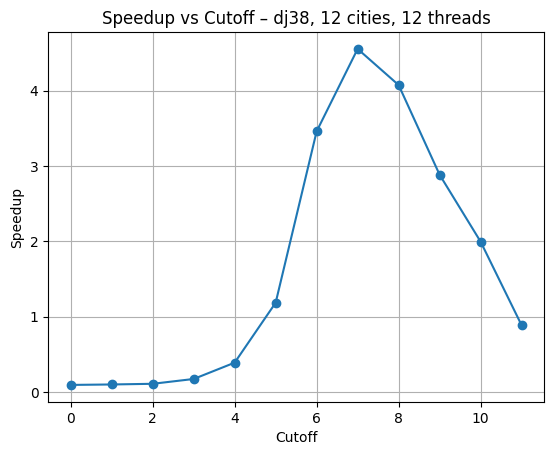

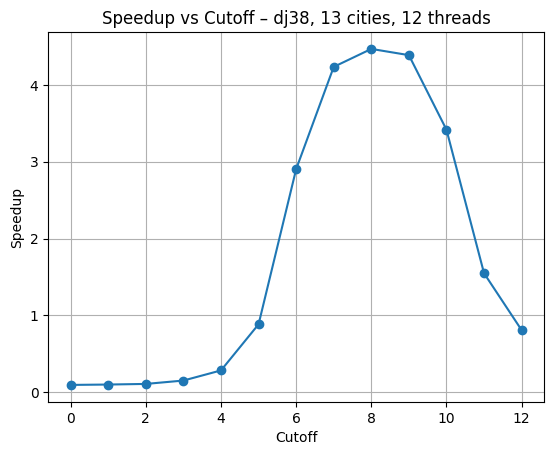

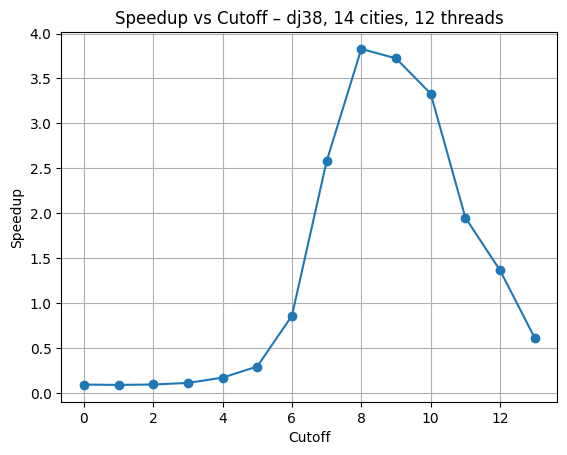

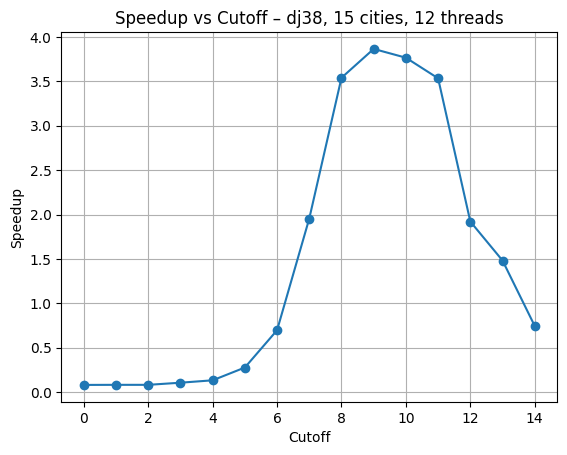

In [31]:

def plot_speedup_vs_cutoff(df, tsp, cities, threads):
    sub = df[
        (df["tsp_file"] == tsp) &
        (df["cities"] == cities) &
        (df["threads"] == threads) &
        (df["run_type"] == "Parallel")
    ].sort_values("cutoff")

    plt.figure()
    plt.plot(sub["cutoff"], sub["speedup"], marker="o")
    plt.xlabel("Cutoff")
    plt.ylabel("Speedup")
    plt.title(f"Speedup vs Cutoff – {tsp}, {cities} cities, {threads} threads")
    plt.grid(True)
    plt.show()

plot_speedup_vs_cutoff(df, "dj38", 12, 12)
plot_speedup_vs_cutoff(df, "dj38", 13, 12)
plot_speedup_vs_cutoff(df, "dj38", 14, 12)
plot_speedup_vs_cutoff(df, "dj38", 15, 12)


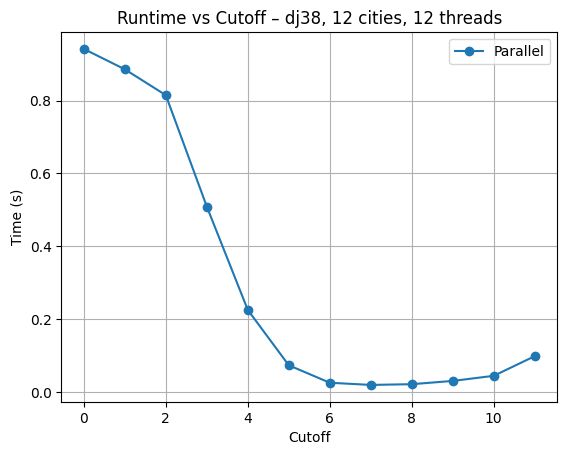

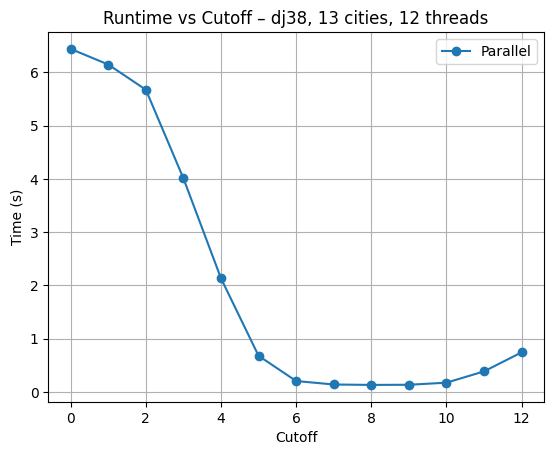

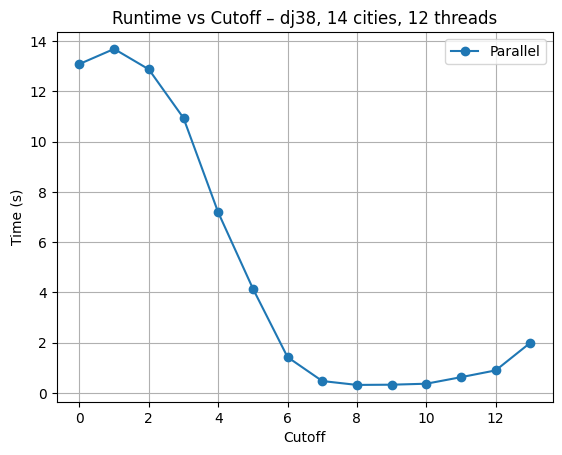

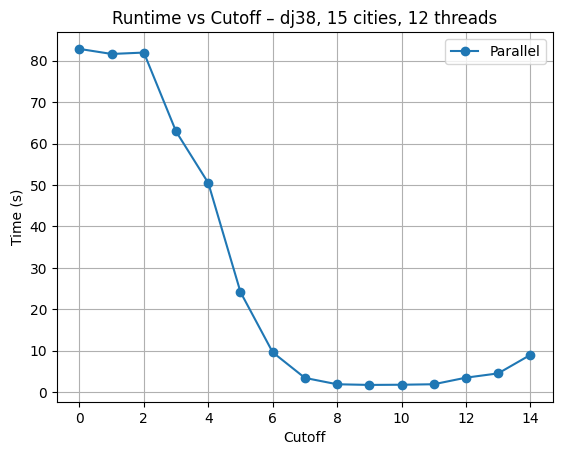

In [25]:
def plot_runtime_vs_cutoff(df, tsp, cities, threads):
    sub = df[
        (df["tsp_file"] == tsp) &
        (df["cities"] == cities) &
        (df["threads"] == threads)
    ].sort_values("cutoff")

    plt.figure()
    for rt in ["Parallel"]:
        s = sub[sub["run_type"] == rt]
        plt.plot(s["cutoff"], s["time_s"], marker="o", label=rt)

    plt.xlabel("Cutoff")
    plt.ylabel("Time (s)")
    plt.title(f"Runtime vs Cutoff – {tsp}, {cities} cities, {threads} threads")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_runtime_vs_cutoff(df, "dj38", 12, 12)
plot_runtime_vs_cutoff(df, "dj38", 13, 12)
plot_runtime_vs_cutoff(df, "dj38", 14, 12)
plot_runtime_vs_cutoff(df, "dj38", 15, 12)

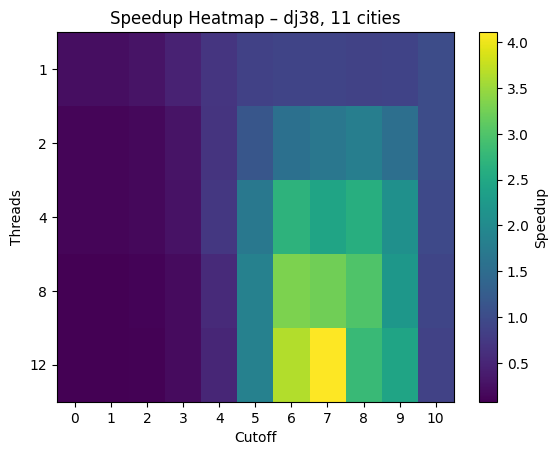

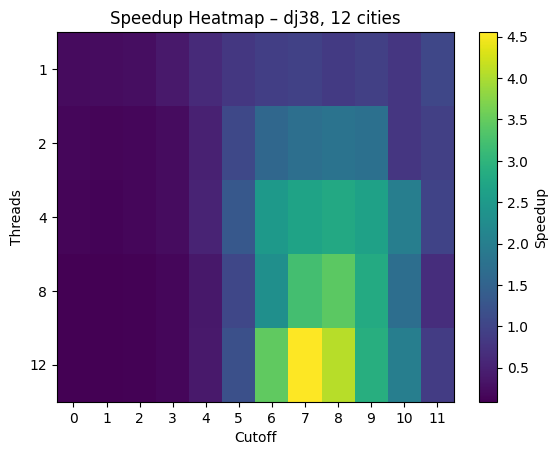

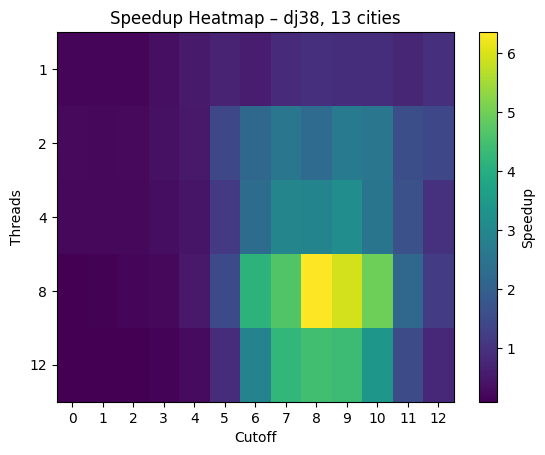

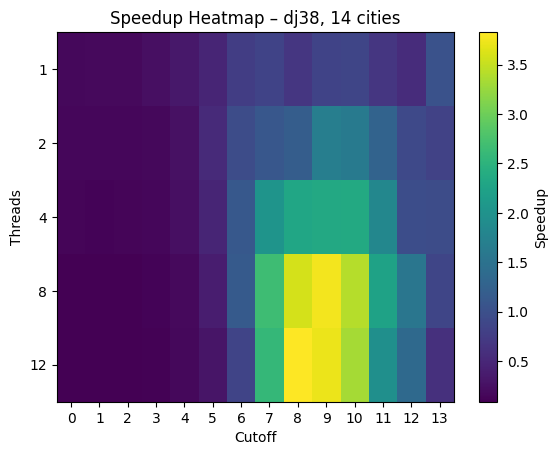

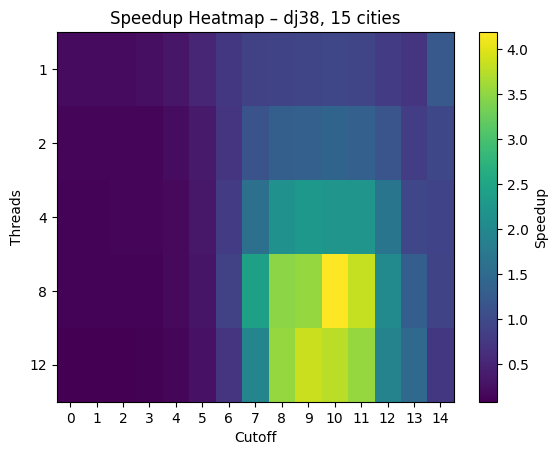

In [19]:
def plot_speedup_heatmap(df, tsp, cities):
    sub = df[
        (df["tsp_file"] == tsp) &
        (df["cities"] == cities) &
        (df["run_type"] == "Parallel")
    ]

    pivot = sub.pivot_table(
        index="threads",
        columns="cutoff",
        values="speedup",
        aggfunc="max"
    )

    plt.figure()
    plt.imshow(pivot, aspect="auto")
    plt.colorbar(label="Speedup")
    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.xlabel("Cutoff")
    plt.ylabel("Threads")
    plt.title(f"Speedup Heatmap – {tsp}, {cities} cities")
    plt.show()


plot_speedup_heatmap(df, "dj38", 11)
plot_speedup_heatmap(df, "dj38", 12)
plot_speedup_heatmap(df, "dj38", 13)
plot_speedup_heatmap(df, "dj38", 14)
plot_speedup_heatmap(df, "dj38", 15)

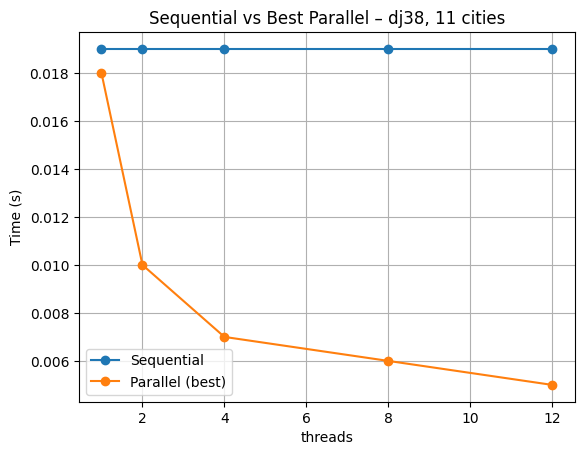

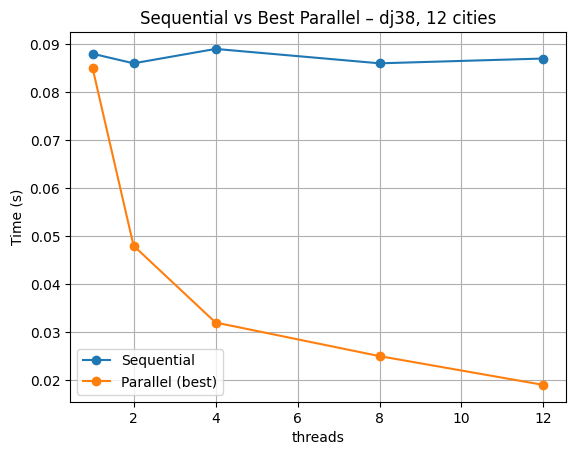

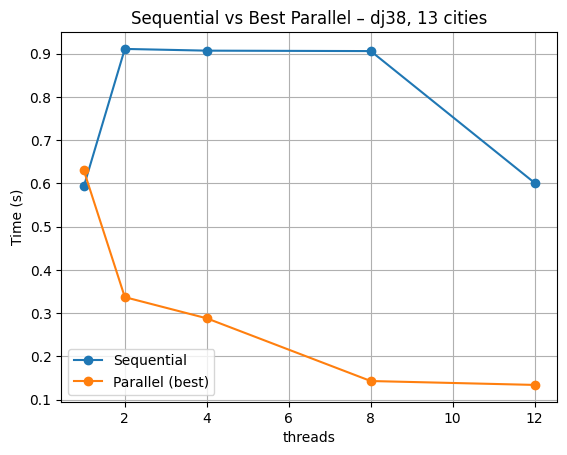

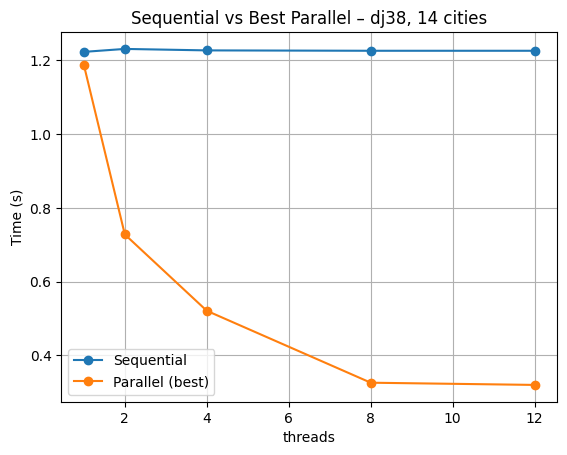

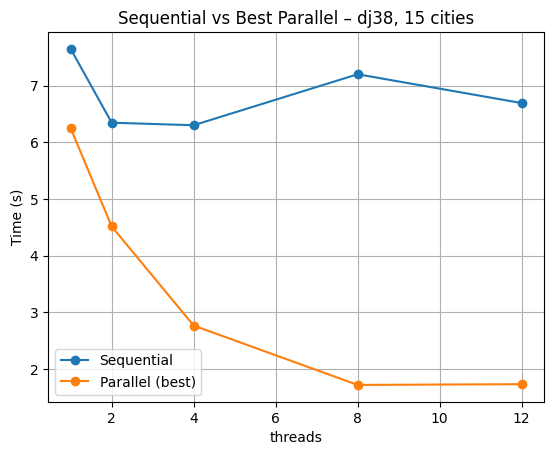

In [21]:
def plot_seq_vs_best_parallel(df, tsp, cities):
    seq = df[
        (df["tsp_file"] == tsp) &
        (df["cities"] == cities) &
        (df["run_type"] == "Sequential")
    ].groupby("threads")["time_s"].min()

    par = df[
        (df["tsp_file"] == tsp) &
        (df["cities"] == cities) &
        (df["run_type"] == "Parallel")
    ].groupby("threads")["time_s"].min()

    comp = pd.DataFrame({"Sequential": seq, "Parallel (best)": par})

    comp.plot(marker="o")
    plt.ylabel("Time (s)")
    plt.title(f"Sequential vs Best Parallel – {tsp}, {cities} cities")
    plt.grid(True)
    plt.show()


plot_seq_vs_best_parallel(df, "dj38", 11)
plot_seq_vs_best_parallel(df, "dj38", 12)
plot_seq_vs_best_parallel(df, "dj38", 13)
plot_seq_vs_best_parallel(df, "dj38", 14)
plot_seq_vs_best_parallel(df, "dj38", 15)

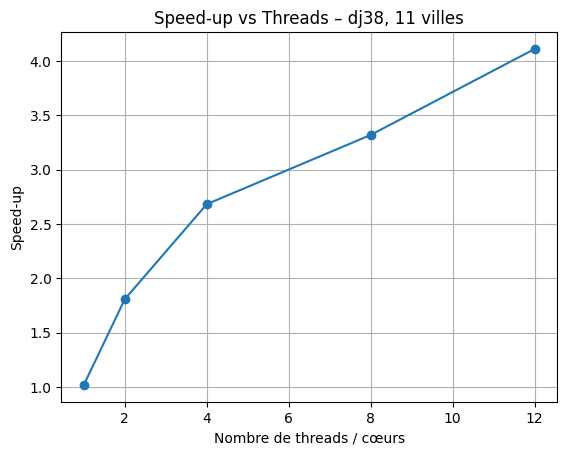

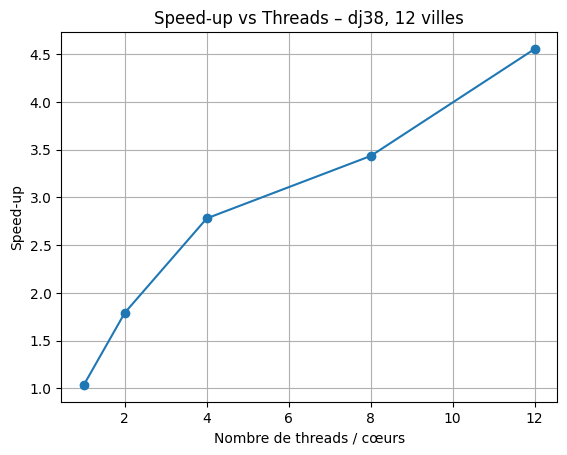

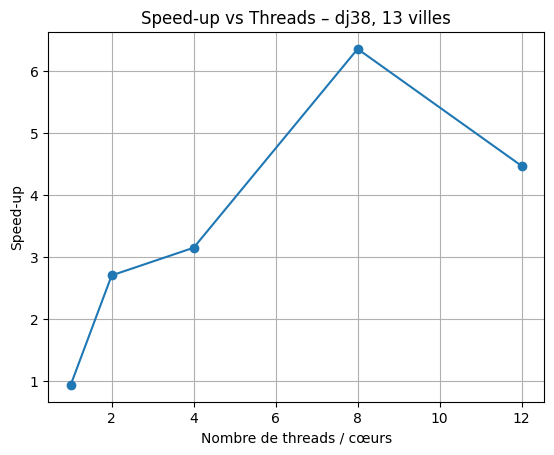

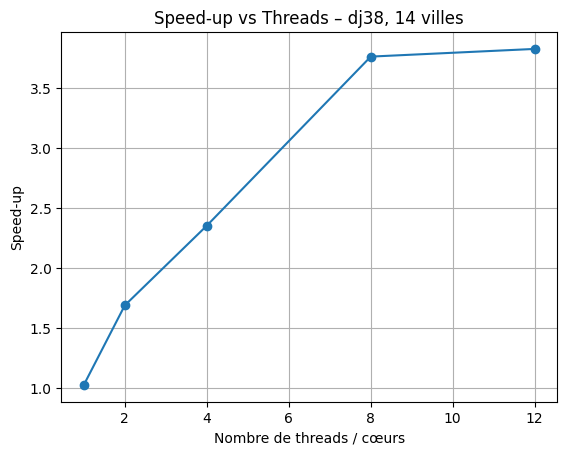

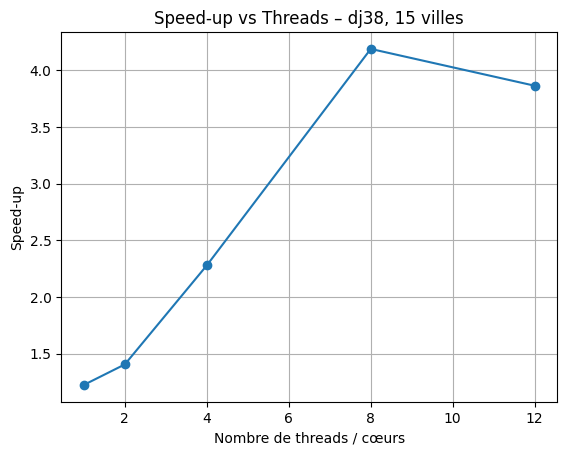

In [30]:

def plot_speedup_vs_threads(df, tsp, cities):
    sub = df[
        (df["tsp_file"] == tsp) &
        (df["cities"] == cities) &
        (df["run_type"] == "Parallel")
    ]

    best = (
        sub.groupby("threads")["speedup"]
        .max()
        .reset_index()
        .sort_values("threads")
    )

    plt.figure()
    plt.plot(best["threads"], best["speedup"], marker="o")
    plt.xlabel("Nombre de threads / cœurs")
    plt.ylabel("Speed-up")
    plt.title(f"Speed-up vs Threads – {tsp}, {cities} villes")
    plt.grid(True)
    plt.show()

plot_speedup_vs_threads(df, "dj38", 11)
plot_speedup_vs_threads(df, "dj38", 12)
plot_speedup_vs_threads(df, "dj38", 13)
plot_speedup_vs_threads(df, "dj38", 14)
plot_speedup_vs_threads(df, "dj38", 15)

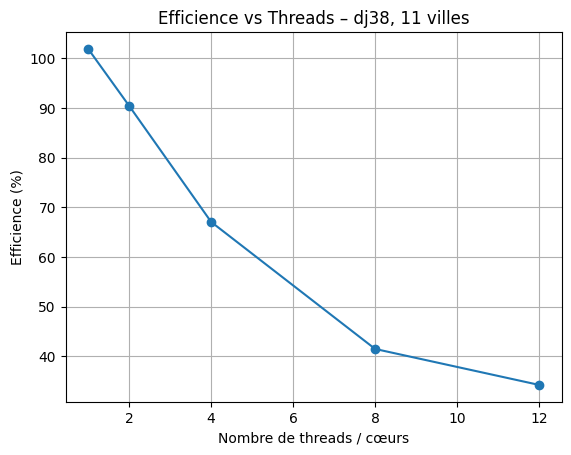

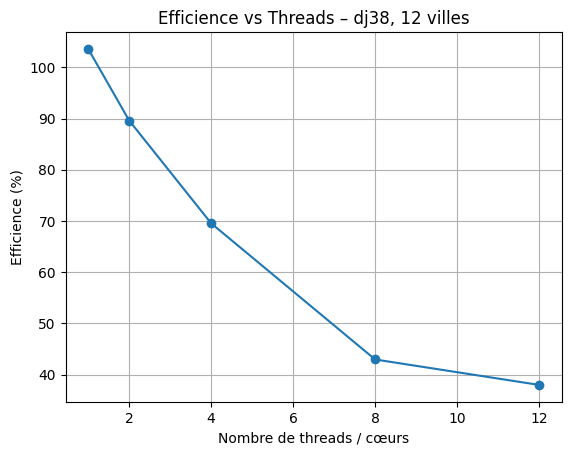

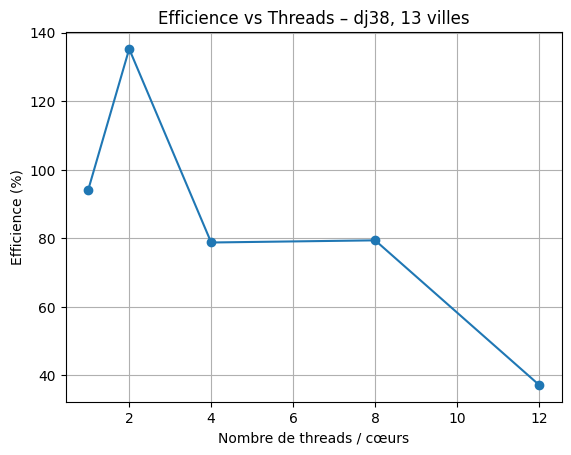

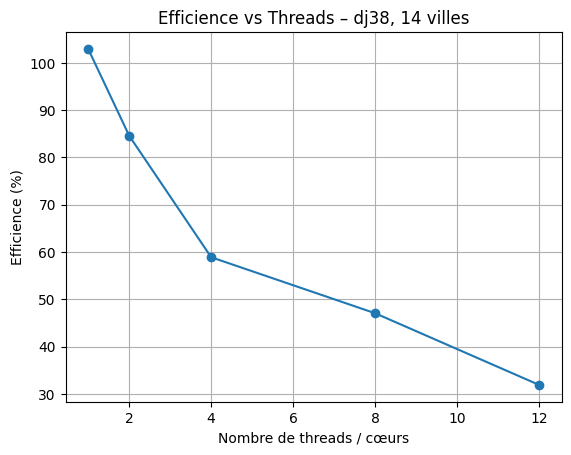

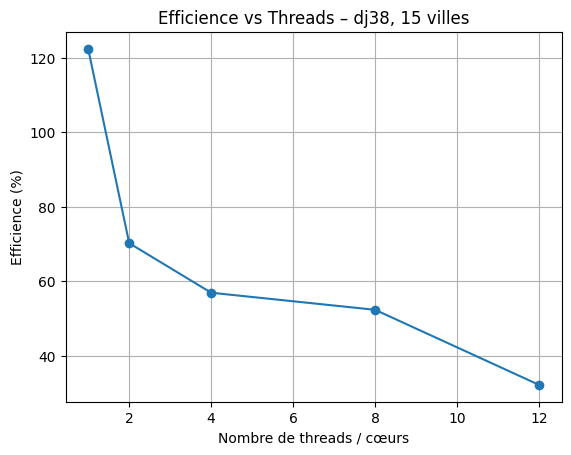

In [29]:
def plot_efficiency_vs_threads(df, tsp, cities):
    sub = df[
        (df["tsp_file"] == tsp) &
        (df["cities"] == cities) &
        (df["run_type"] == "Parallel")
    ]

    best = (
        sub.groupby("threads")["efficiency_pct"]
        .max()
        .reset_index()
        .sort_values("threads")
    )

    plt.figure()
    plt.plot(best["threads"], best["efficiency_pct"], marker="o")
    plt.xlabel("Nombre de threads / cœurs")
    plt.ylabel("Efficience (%)")
    plt.title(f"Efficience vs Threads – {tsp}, {cities} villes")
    plt.grid(True)
    plt.show()

plot_efficiency_vs_threads(df, "dj38", 11)
plot_efficiency_vs_threads(df, "dj38", 12)
plot_efficiency_vs_threads(df, "dj38", 13)
plot_efficiency_vs_threads(df, "dj38", 14)
plot_efficiency_vs_threads(df, "dj38", 15)